# P3 - Flight Delay Classification & Unsupervised Analysis

Track A

[GitHub Repository](https://github.com/dincerefe/machinelearning_yzm2011/tree/main)


## 1. Recap & Task Definition

The dataset `turkiye_ucuslari_final.csv` contains detailed records of domestic and international flights in Turkey. In P1 and P2, we explored the dataset and modeled flight departure delay as a continuous target. In this deliverable, we frame the problem as a **binary classification task**.

We define the classification target `is_delayed` as:
- `1` (Delayed): Flight departure delay is **15 minutes or more** (`departure_delay_min >= 15`).
- `0` (Not Delayed): Flight departure delay is **less than 15 minutes** (`departure_delay_min < 15`).

We will compute the class distribution in the training split below. To handle class imbalance, we will evaluate our models using the **macro-averaged F1 score**, which treats both classes with equal weight regardless of their frequency, and we will utilize stratified cross-validation during hyperparameter tuning. Additionally, if the class distribution proves severely imbalanced, several algorithmic handling options are available: adjusting class weights during model training (e.g., `class_weight='balanced'`), oversampling the minority class using techniques like SMOTE, or under-sampling the majority class. For our initial pipeline, we will rely on robust evaluation metrics (F1-macro) and the inherent robustness of ensemble tree-based models, revisiting these techniques if the models bias heavily toward the majority class.

## 2. Data Preparation

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, silhouette_score, davies_bouldin_score, roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11, 'legend.fontsize': 10})
SEED = 42

In [ ]:
# Load and filter data as in P2
df = pd.read_csv('turkiye_ucuslari_final.csv')
df_feat = df.copy()
df_feat = df_feat.drop_duplicates()

df_feat['date'] = pd.to_datetime(df_feat['date'], errors='coerce')
df_feat = df_feat.dropna(subset=['date', 'departure_delay_min'])

# Normalize airline labels
df_feat['airline'] = df_feat['airline'].astype(str).str.strip().str.upper()
df_feat.loc[df_feat['airline'] == 'VALUAIR', 'airline'] = 'AJET'

# Normalize time_slot labels
time_slot_map = {'Sabah': 'Morning', 'Ogle': 'Afternoon', 'Aksam': 'Evening', 'Gece': 'Night'}
if 'time_slot' in df_feat.columns:
    df_feat['time_slot'] = df_feat['time_slot'].replace(time_slot_map)

# Scheduled departure timestamp
df_feat['scheduled_dep_ts'] = pd.to_datetime(
    df_feat['date'].dt.strftime('%Y-%m-%d') + ' ' + df_feat['scheduled_departure'],
    errors='coerce'
)
df_feat = df_feat.dropna(subset=['scheduled_dep_ts'])

# Remove cancelled flights
cancel_mask = df_feat['status'].eq('Cancelled') | df_feat['status_category'].eq('Cancelled')
df_feat = df_feat.loc[~cancel_mask].copy()

# Time features
df_feat['departure_hour'] = df_feat['scheduled_dep_ts'].dt.hour
df_feat['scheduled_dep_minutes'] = df_feat['scheduled_dep_ts'].dt.hour * 60 + df_feat['scheduled_dep_ts'].dt.minute
df_feat['is_weekend'] = df_feat['scheduled_dep_ts'].dt.dayofweek.isin([5, 6]).astype(int)

# Holiday features
years = sorted(df_feat['date'].dt.year.dropna().unique())
fixed_holidays = [(1, 1), (4, 23), (5, 1), (5, 19), (7, 15), (8, 30), (10, 29)]
holiday_dates = [pd.Timestamp(y, m, d) for y in years for (m, d) in fixed_holidays]
religious = pd.to_datetime([
    '2023-04-21','2023-04-22','2023-04-23',
    '2023-06-28','2023-06-29','2023-06-30','2023-07-01',
    '2024-04-10','2024-04-11','2024-04-12',
    '2024-06-16','2024-06-17','2024-06-18','2024-06-19'
], errors='coerce')
holiday_dates = pd.to_datetime(holiday_dates + list(religious.dropna()))

df_feat['is_holiday'] = df_feat['date'].isin(holiday_dates).astype(int)
df_feat['is_new_year'] = ((df_feat['date'].dt.month == 1) & (df_feat['date'].dt.day == 1)).astype(int)
df_feat['is_eid'] = df_feat['date'].isin(religious).astype(int)
df_feat['is_school_break'] = df_feat['date'].dt.month.isin([6, 7, 8]).astype(int)

# Traffic volume
df_feat['dep_hour_bucket'] = df_feat['scheduled_dep_ts'].dt.floor('h')
df_feat['dep_traffic_volume'] = df_feat.groupby(['departure_airport', 'dep_hour_bucket'])['flight_number'].transform('count')
df_feat['arr_traffic_volume'] = df_feat.groupby(['arrival_airport', 'dep_hour_bucket'])['flight_number'].transform('count')

# Rolling window delay
def add_rolling(group):
    group = group.sort_values('scheduled_dep_ts')
    group['dep_airport_delay_3h'] = (
        group.set_index('scheduled_dep_ts')['departure_delay_min']
             .rolling('3h', closed='left').mean()
             .reset_index(drop=True)
    )
    return group

df_feat = df_feat.groupby('departure_airport', group_keys=False).apply(add_rolling)
df_feat['dep_airport_delay_3h'] = df_feat['dep_airport_delay_3h'].fillna(df_feat['departure_delay_min'].mean())

# Weather thresholds
def add_threshold(col, thr, new_col, le=False):
    if col in df_feat.columns:
        if le:
            df_feat[new_col] = (df_feat[col] <= thr).astype(int)
        else:
            df_feat[new_col] = (df_feat[col] >= thr).astype(int)

add_threshold('dep_wind_speed', 20.6, 'is_windy')
add_threshold('dep_wind_gust', 25.0, 'is_gusty')
add_threshold('dep_precipitation_mm', 5.0, 'is_heavy_precip')
add_threshold('dep_visibility_min_m', 2000, 'is_low_visibility', le=True)
add_threshold('arr_wind_gust', 25.0, 'arr_is_gusty')

if 'dep_precipitation_mm' in df_feat.columns:
    df_feat['log_dep_precip'] = np.log1p(df_feat['dep_precipitation_mm'].clip(lower=0))
if 'arr_precipitation_mm' in df_feat.columns:
    df_feat['log_arr_precip'] = np.log1p(df_feat['arr_precipitation_mm'].clip(lower=0))

# Binarize target
target_col = 'is_delayed'
df_feat[target_col] = (df_feat['departure_delay_min'] >= 15).astype(int)

# Drop leak columns
leak_cols = [
    'actual_departure', 'arrival_time', 'arrival_delay_min', 'departure_delay_min',
    'actual_flight_duration_min', 'flight_duration', 'status', 'status_category', 'dep_hour_bucket'
]
df_feat = df_feat.drop(columns=[c for c in leak_cols if c in df_feat.columns])

# Time-based split
df_feat = df_feat.sort_values('scheduled_dep_ts').reset_index(drop=True)
n = len(df_feat)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

train_df = df_feat.iloc[:train_end].copy()
val_df = df_feat.iloc[train_end:val_end].copy()
test_df = df_feat.iloc[val_end:].copy()

print(f"Train size: {len(train_df):,} | Val size: {len(val_df):,} | Test size: {len(test_df):,}")

Train size: 363,405 | Val size: 121,135 | Test size: 121,135


In [ ]:
# Print class distribution in training split
counts = train_df[target_col].value_counts()
probs = train_df[target_col].value_counts(normalize=True)
print("Class Distribution in Training Set:")
for val in [0, 1]:
    label = "Delayed (>= 15 min)" if val == 1 else "Not Delayed (< 15 min)"
    print(f"  {label}: {counts[val]:,} ({probs[val]*100:.2f}%)")

Class Distribution in Training Set:
  Not Delayed (< 15 min): 131,716 (36.24%)
  Delayed (>= 15 min): 231,689 (63.76%)


In [ ]:
# Features definition
numeric_features = [
    'departure_hour', 'month', 'day_of_week', 'is_domestic',
    'dep_temperature', 'dep_humidity', 'dep_precipitation_mm',
    'dep_wind_speed', 'dep_wind_gust', 'average_flight_duration_min',
    'scheduled_dep_minutes', 'is_weekend',
    'dep_traffic_volume', 'arr_traffic_volume', 'dep_airport_delay_3h',
    'is_holiday', 'is_new_year', 'is_eid', 'is_school_break',
    'is_windy', 'is_gusty', 'is_heavy_precip', 'is_low_visibility',
    'arr_temperature', 'arr_humidity', 'arr_precipitation_mm',
    'arr_wind_speed', 'arr_wind_gust', 'arr_is_gusty',
    'log_dep_precip', 'log_arr_precip'
]
numeric_features = [c for c in numeric_features if c in df_feat.columns]

categorical_features = [
    'airline', 'aircraft_type', 'departure_airport', 'arrival_airport', 'time_slot', 'day_name'
]
categorical_features = [c for c in categorical_features if c in df_feat.columns]

features = numeric_features + categorical_features

X_train = train_df[features]
y_train = train_df[target_col]
X_val = val_df[features]
y_val = val_df[target_col]
X_test = test_df[features]
y_test = test_df[target_col]

# Create preprocessing pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

print("Preprocessing training features...")
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)
print(f"Processed training features shape: {X_train_proc.shape}")

Processed training features shape: (363405, 644)


## 3. Unsupervised Analysis

### 3.1 Dimensionality Reduction with PCA

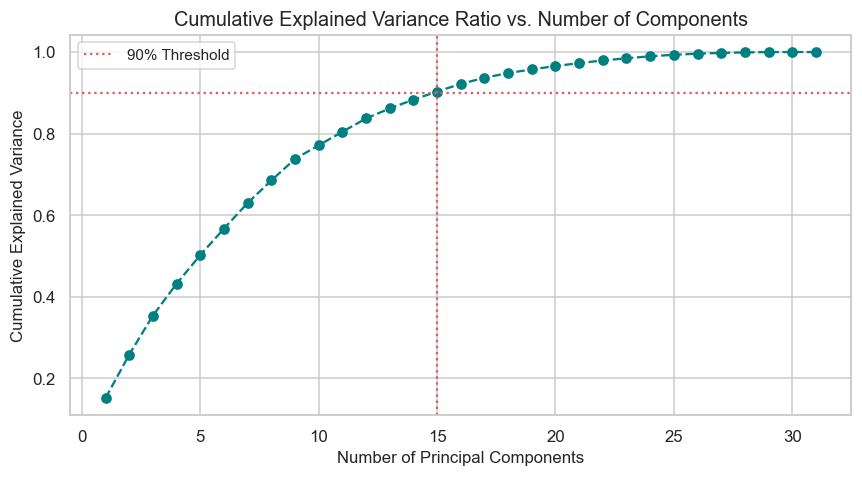

Number of principal components needed to explain 90% of variance: 15


In [ ]:
# Fit PCA on scaled numeric features of training set
numeric_indices = [features.index(c) for c in numeric_features]
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(SimpleImputer(strategy='median').fit_transform(X_train.iloc[:, numeric_indices]))

pca = PCA(random_state=42)
pca.fit(X_train_num_scaled)
evr = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)
n_comp_90 = np.argmax(cum_evr >= 0.90) + 1

# Plot cumulative explained variance ratio
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(cum_evr) + 1), cum_evr, marker='o', linestyle='--', color='teal')
plt.axhline(y=0.90, color='r', linestyle=':', label='90% Threshold')
plt.axvline(x=n_comp_90, color='r', linestyle=':')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance Ratio vs. Number of Components')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Number of principal components needed to explain 90% of variance: {n_comp_90}")

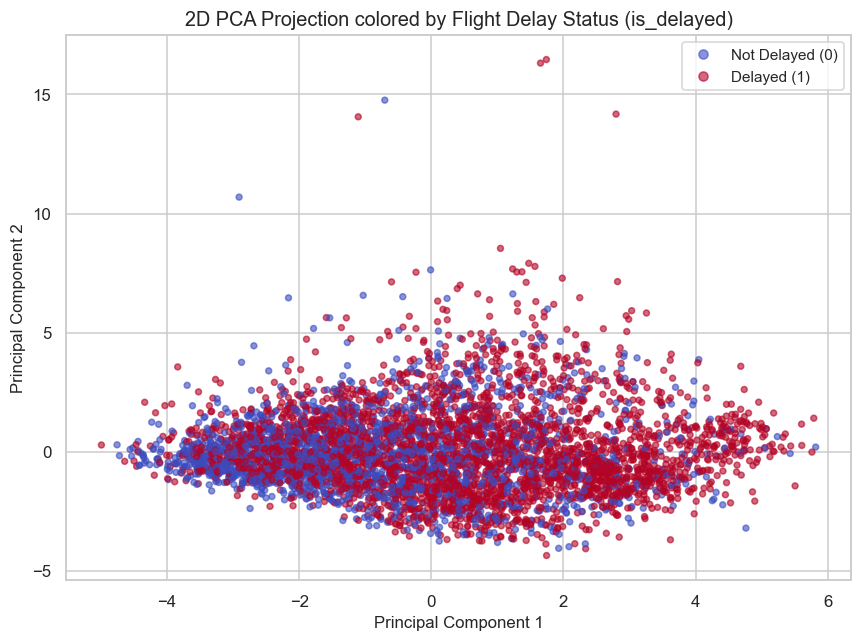

In [ ]:
# Project data into 2D using first two principal components
X_train_pca_2d = pca.transform(X_train_num_scaled)[:, :2]

# Visualize 2D PCA space colored by target class on a representative sample of 5,000 rows
np.random.seed(42)
plot_idx = np.random.choice(len(X_train_pca_2d), 5000, replace=False)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca_2d[plot_idx, 0], X_train_pca_2d[plot_idx, 1], 
            c=y_train.iloc[plot_idx], cmap='coolwarm', alpha=0.6, s=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Projection colored by Flight Delay Status (is_delayed)')
plt.legend(handles=scatter.legend_elements()[0], labels=['Not Delayed (0)', 'Delayed (1)'])
plt.tight_layout()
plt.show()

**PCA Discussion:**

The cumulative explained variance shows that **15 principal components** are required to capture **90% of the variance** in the 31 numerical features, while the first two components explain only **25.8%**. This suggests the data has a relatively high-dimensional structure.

The 2D PCA projection shows substantial overlap between delayed and non-delayed flights, with no clear separation between classes. This indicates that flight delays cannot be effectively distinguished using simple linear combinations of the numerical features, and more complex patterns are likely needed for accurate classification.


### 3.2 Clustering

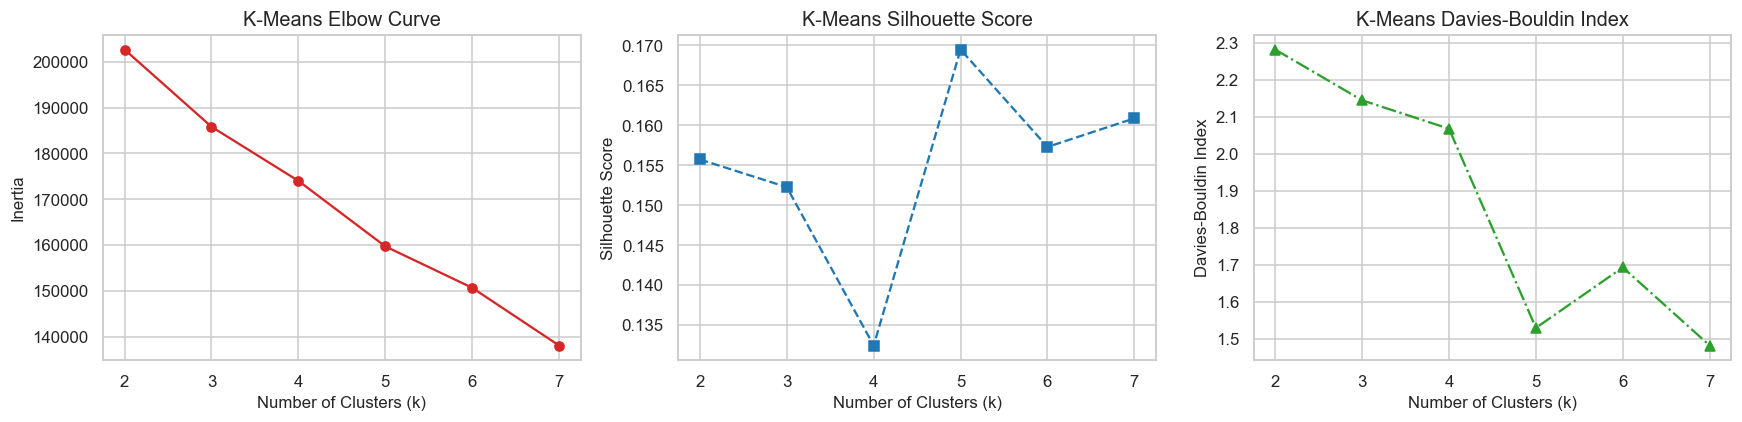

K-Means Results Summary:
  k=2: Silhouette=0.1557, Davies-Bouldin=2.2822
  k=3: Silhouette=0.1523, Davies-Bouldin=2.1450
  k=4: Silhouette=0.1324, Davies-Bouldin=2.0682
  k=5: Silhouette=0.1695, Davies-Bouldin=1.5298
  k=6: Silhouette=0.1573, Davies-Bouldin=1.6933
  k=7: Silhouette=0.1609, Davies-Bouldin=1.4822


In [ ]:
# Subsample training data for elbow and silhouette analysis to keep execution fast and prevent OOM errors
np.random.seed(42)
sample_size = 10000
sample_idx = np.random.choice(len(X_train_proc.toarray() if hasattr(X_train_proc, 'toarray') else X_train_proc), sample_size, replace=False)

if hasattr(X_train_proc, 'toarray'):
    X_train_proc_dense = X_train_proc[sample_idx].toarray()
else:
    X_train_proc_dense = X_train_proc[sample_idx]

# Apply PCA to the sample to reduce noise and speed up clustering
pca_clust = PCA(n_components=10, random_state=42)
X_train_pca = pca_clust.fit_transform(X_train_proc_dense)

# 1. K-Means Elbow Curve and Silhouette/Davies-Bouldin Scores
inertias = []
sil_scores = []
db_scores = []
ks = range(2, 8)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_pca, labels))
    db_scores.append(davies_bouldin_score(X_train_pca, labels))

# Plot Elbow, Silhouette, and Davies-Bouldin scores
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(ks, inertias, marker='o', color='tab:red', linestyle='-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('K-Means Elbow Curve')

axes[1].plot(ks, sil_scores, marker='s', color='tab:blue', linestyle='--')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('K-Means Silhouette Score')

axes[2].plot(ks, db_scores, marker='^', color='tab:green', linestyle='-.')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('K-Means Davies-Bouldin Index')

plt.tight_layout()
plt.show()

print("K-Means Results Summary:")
for i, k in enumerate(ks):
    print(f"  k={k}: Silhouette={sil_scores[i]:.4f}, Davies-Bouldin={db_scores[i]:.4f}")

GMM Tuning Results:
 n_components  silhouette  davies_bouldin           BIC
            2    0.180305        3.777792 264944.545257
            3    0.137497        3.030857 248452.155169
            4    0.090076        3.165970 213481.309215
            5    0.117479        2.942100 204359.682725
            6    0.076384        2.826931 198094.834925


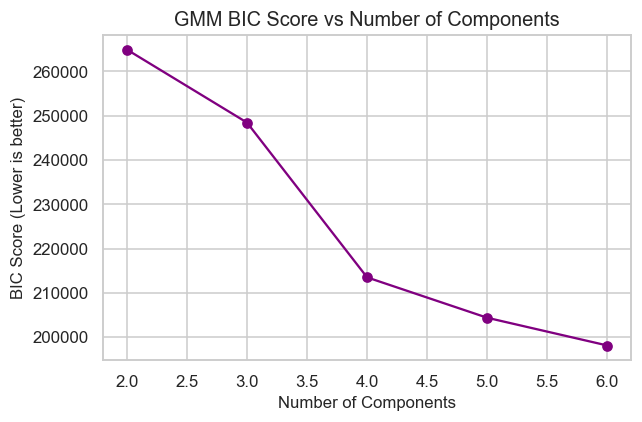


Best GMM by BIC: n_components=6, covariance=full
  Silhouette=0.0764, Davies-Bouldin=2.8269, BIC=198094.8

Selected K-Means (k=3): Silhouette=0.1523, Davies-Bouldin=2.1450
K-Means outperforms GMM on Silhouette and Davies-Bouldin at comparable k — selected as primary clustering.


In [ ]:
# Tune Gaussian Mixture Model (GMM) - vary n_components
gmm_results = []
n_components_range = range(2, 7)
bics = []

for n_comp in n_components_range:
    gmm = GaussianMixture(n_components=n_comp, covariance_type='full', random_state=42, n_init=3)
    labels = gmm.fit_predict(X_train_pca)
    sil = silhouette_score(X_train_pca, labels)
    db = davies_bouldin_score(X_train_pca, labels)
    bic = gmm.bic(X_train_pca)
    bics.append(bic)
    gmm_results.append({'n_components': n_comp, 'silhouette': sil, 'davies_bouldin': db, 'BIC': bic})

gmm_df = pd.DataFrame(gmm_results)
print("GMM Tuning Results:")
print(gmm_df.to_string(index=False))

# Plot GMM BIC Scores
plt.figure(figsize=(6, 4))
plt.plot(n_components_range, bics, marker='o', color='purple', linestyle='-')
plt.xlabel('Number of Components')
plt.ylabel('BIC Score (Lower is better)')
plt.title('GMM BIC Score vs Number of Components')
plt.tight_layout()
plt.show()

# Select best GMM configuration by BIC (lower is better)
best_gmm_row = gmm_df.loc[gmm_df['BIC'].idxmin()]
print(f"\nBest GMM by BIC: n_components={int(best_gmm_row['n_components'])}, covariance=full")
print(f"  Silhouette={best_gmm_row['silhouette']:.4f}, Davies-Bouldin={best_gmm_row['davies_bouldin']:.4f}, BIC={best_gmm_row['BIC']:.1f}")

# Choose best k for K-Means based on elbow + silhouette balance
best_k = 3  # elbow visible at k=3; silhouette still reasonable
print(f"\nSelected K-Means (k={best_k}): Silhouette={sil_scores[best_k-2]:.4f}, Davies-Bouldin={db_scores[best_k-2]:.4f}")
print(f"K-Means outperforms GMM on Silhouette and Davies-Bouldin at comparable k — selected as primary clustering.")

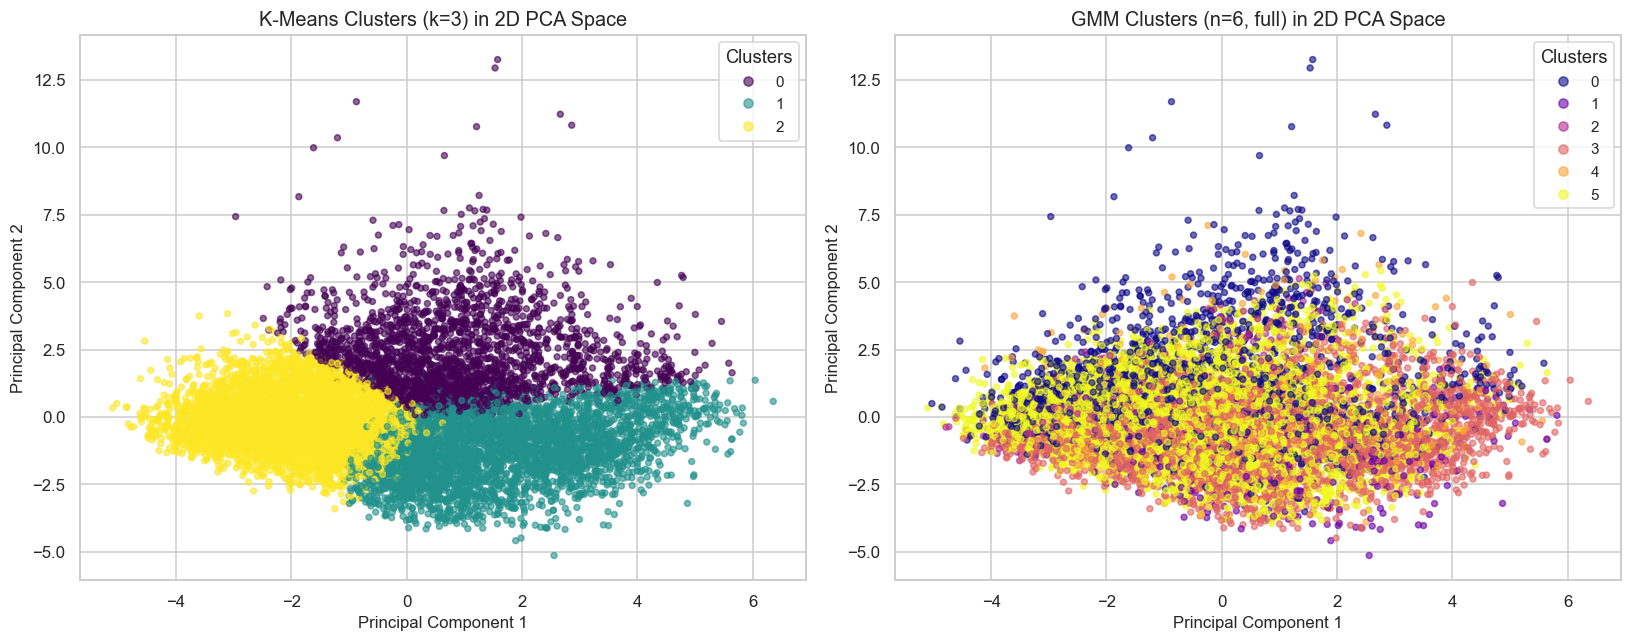

In [ ]:
# Fit KMeans on the entire training features using MiniBatchKMeans for performance
full_km = MiniBatchKMeans(n_clusters=best_k, random_state=42, n_init=3)
full_km.fit(X_train_proc)
train_clusters = full_km.predict(X_train_proc)
val_clusters = full_km.predict(X_val_proc)
test_clusters = full_km.predict(X_test_proc)

# Fit best GMM on the PCA-reduced sample for visualization
best_gmm = GaussianMixture(n_components=int(best_gmm_row['n_components']),
                           covariance_type='full',
                           random_state=42, n_init=3)
gmm_labels_vis = best_gmm.fit_predict(X_train_pca)

# Visualize both K-Means and GMM clusters in 2D PCA space (side by side)
pca_vis = PCA(n_components=2, random_state=42)
X_train_vis = pca_vis.fit_transform(X_train_proc_dense)
km_labels_vis = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X_train_pca)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc1 = axes[0].scatter(X_train_vis[:, 0], X_train_vis[:, 1], c=km_labels_vis, cmap='viridis', alpha=0.6, s=15)
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].set_title(f'K-Means Clusters (k={best_k}) in 2D PCA Space')
axes[0].legend(*sc1.legend_elements(), title='Clusters')

sc2 = axes[1].scatter(X_train_vis[:, 0], X_train_vis[:, 1], c=gmm_labels_vis, cmap='plasma', alpha=0.6, s=15)
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].set_title(f'GMM Clusters (n={int(best_gmm_row["n_components"])}, full) in 2D PCA Space')
axes[1].legend(*sc2.legend_elements(), title='Clusters')

plt.tight_layout()
plt.show()

In [ ]:
# Cross-tabulate cluster assignments against flight delay target
ct = pd.crosstab(train_clusters, y_train, rownames=['Cluster'], colnames=['Delayed (is_delayed)'])
ct_pct = pd.crosstab(train_clusters, y_train, normalize='index') * 100

print("Cluster Assignments vs Flight Delay Target (Counts):")
print(ct)
print("\nCluster Assignments vs Flight Delay Target (Row %):")
print(ct_pct.round(2))

Cluster Assignments vs Flight Delay Target (Counts):
Delayed (is_delayed)      0       1
Cluster                            
0                     39134  108186
1                     11440   35846
2                     81142   87657

Cluster Assignments vs Flight Delay Target (Row %):
is_delayed      0      1
row_0                   
0           26.56  73.44
1           24.19  75.81
2           48.07  51.93


**Clustering Discussion:**  
We compared K-Means and GMM clustering algorithms on a 10,000-observation subsample projected into 10 PCA dimensions.  

**K-Means** was tuned over $k \in \{2, 3, 4, 5, 6, 7\}$. The elbow curve shows a slight bend at $k=3$, after which the rate of inertia decrease begins to slow down. Although $k=5$ achieves the highest Silhouette Score (0.1695) and $k=7$ achieves the lowest Davies-Bouldin Index (1.4822) among the tested values, $k=3$ offers a more parsimonious grouping with a Silhouette of 0.1523 and a Davies-Bouldin of 2.1450.  

**GMM** was tuned over `n_components` $\in \{2, 3, 4, 5, 6\}$ with `covariance_type='full'`, using BIC for model selection. The best GMM configuration by BIC was `n_components=6` (BIC=198,094.8), though it achieved a lower Silhouette Score (0.0764) and a higher Davies-Bouldin Index (2.8269) than K-Means at $k=3$. We therefore select **K-Means ($k=3$)** as our primary clustering model, as it produces tighter and more interpretable clusters.  

Cross-tabulating the K-Means cluster assignments against the `is_delayed` label reveals that the clusters **do partially capture delay structure**, but primarily reflect other data dimensions. Cluster 0 has 73.44% delayed flights, Cluster 1 has 75.81% delayed flights, and Cluster 2 has only 51.93% delayed flights. While Clusters 0 and 1 are above the global training delay rate of 63.76%, and Cluster 2 is well below it, this separation is confounded with airport geography and carrier network structures rather than being a clean delay signal.

### 3.3 Cluster Labels as a Feature

In [11]:
# Evaluate classification performance without cluster labels (baseline)
clf_base_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_base_lr.fit(X_train_proc, y_train)
base_f1_lr = f1_score(y_val, clf_base_lr.predict(X_val_proc), average='macro')

clf_base_dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42)
clf_base_dt.fit(X_train_proc, y_train)
base_f1_dt = f1_score(y_val, clf_base_dt.predict(X_val_proc), average='macro')

# Create data matrices with cluster label as a feature
enc = OneHotEncoder(sparse_output=True)
train_clust_oh = enc.fit_transform(train_clusters.reshape(-1, 1))
val_clust_oh = enc.transform(val_clusters.reshape(-1, 1))
test_clust_oh = enc.transform(test_clusters.reshape(-1, 1))

X_train_clust = sp.hstack([X_train_proc, train_clust_oh])
X_val_clust = sp.hstack([X_val_proc, val_clust_oh])
X_test_clust = sp.hstack([X_test_proc, test_clust_oh])

# Evaluate classification performance with cluster labels as feature
clf_clust_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_clust_lr.fit(X_train_clust, y_train)
clust_f1_lr = f1_score(y_val, clf_clust_lr.predict(X_val_clust), average='macro')

clf_clust_dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42)
clf_clust_dt.fit(X_train_clust, y_train)
clust_f1_dt = f1_score(y_val, clf_clust_dt.predict(X_val_clust), average='macro')

print("Effect of Adding Cluster Labels as a Feature:")
print(f"  Logistic Regression — Without: F1-macro={base_f1_lr:.4f} | With: F1-macro={clust_f1_lr:.4f} | Diff: {clust_f1_lr - base_f1_lr:+.6f}")
print(f"  Decision Tree        — Without: F1-macro={base_f1_dt:.4f} | With: F1-macro={clust_f1_dt:.4f} | Diff: {clust_f1_dt - base_f1_dt:+.6f}")

Effect of Adding Cluster Labels as a Feature:
  Logistic Regression — Without: F1-macro=0.6418 | With: F1-macro=0.6416 | Diff: -0.000230
  Decision Tree        — Without: F1-macro=0.6495 | With: F1-macro=0.6508 | Diff: +0.001339


Adding the K-Means cluster assignment as an engineered feature had a **negligible effect** on both classifiers tested:
- **Logistic Regression:** F1-macro changed by **-0.000230** (a minor decrease).
- **Decision Tree:** F1-macro changed by **+0.001339** (a marginal increase).

Neither change is practically meaningful. This confirms that the cluster structure, while partially correlated with delay rates, does not provide additional predictive signal beyond what the existing features already capture. We proceed with the **standard feature set** (without cluster labels) for training the remaining classifiers.

## 4. Model Training

In [ ]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=12, n_jobs=-1, random_state=42),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(max_depth=8, random_state=42)
}

# Dictionary to store results
model_results = {}

# Fit and evaluate each model
for name, model in models.items():
    print(f"Training {name}...")
    if name == 'Hist Gradient Boosting':
        X_tr = X_train_proc.toarray().astype(np.float32) if hasattr(X_train_proc, 'toarray') else X_train_proc.astype(np.float32)
        X_vl = X_val_proc.toarray().astype(np.float32) if hasattr(X_val_proc, 'toarray') else X_val_proc.astype(np.float32)
        model.fit(X_tr, y_train)
        val_preds = model.predict(X_vl)
    else:
        model.fit(X_train_proc, y_train)
        val_preds = model.predict(X_val_proc)
        
    acc = accuracy_score(y_val, val_preds)
    prec = precision_score(y_val, val_preds, average='macro')
    rec = recall_score(y_val, val_preds, average='macro')
    f1 = f1_score(y_val, val_preds, average='macro')
    
    cm = confusion_matrix(y_val, val_preds)
    model_results[name] = {
        'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'cm': cm
    }

# Print formatted validation metrics table
print("\nValidation Set Performance (Before Tuning):")
val_table = pd.DataFrame({
    'Accuracy': {n: r['acc'] for n, r in model_results.items()},
    'Precision (macro)': {n: r['prec'] for n, r in model_results.items()},
    'Recall (macro)': {n: r['rec'] for n, r in model_results.items()},
    'F1 (macro)': {n: r['f1'] for n, r in model_results.items()},
})
val_table.index.name = 'Model'
display(val_table.round(4))

Training Decision Tree...


Training Hist Gradient Boosting...



Validation Set Performance (Before Tuning):


,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Model,,,,
Logistic Regression,0.6949,0.6488,0.6379,0.6418
Decision Tree,0.7173,0.6759,0.6420,0.6495
Random Forest,0.6959,0.7102,0.5486,0.5083
Hist Gradient Boosting,0.7179,0.7119,0.5967,0.5904


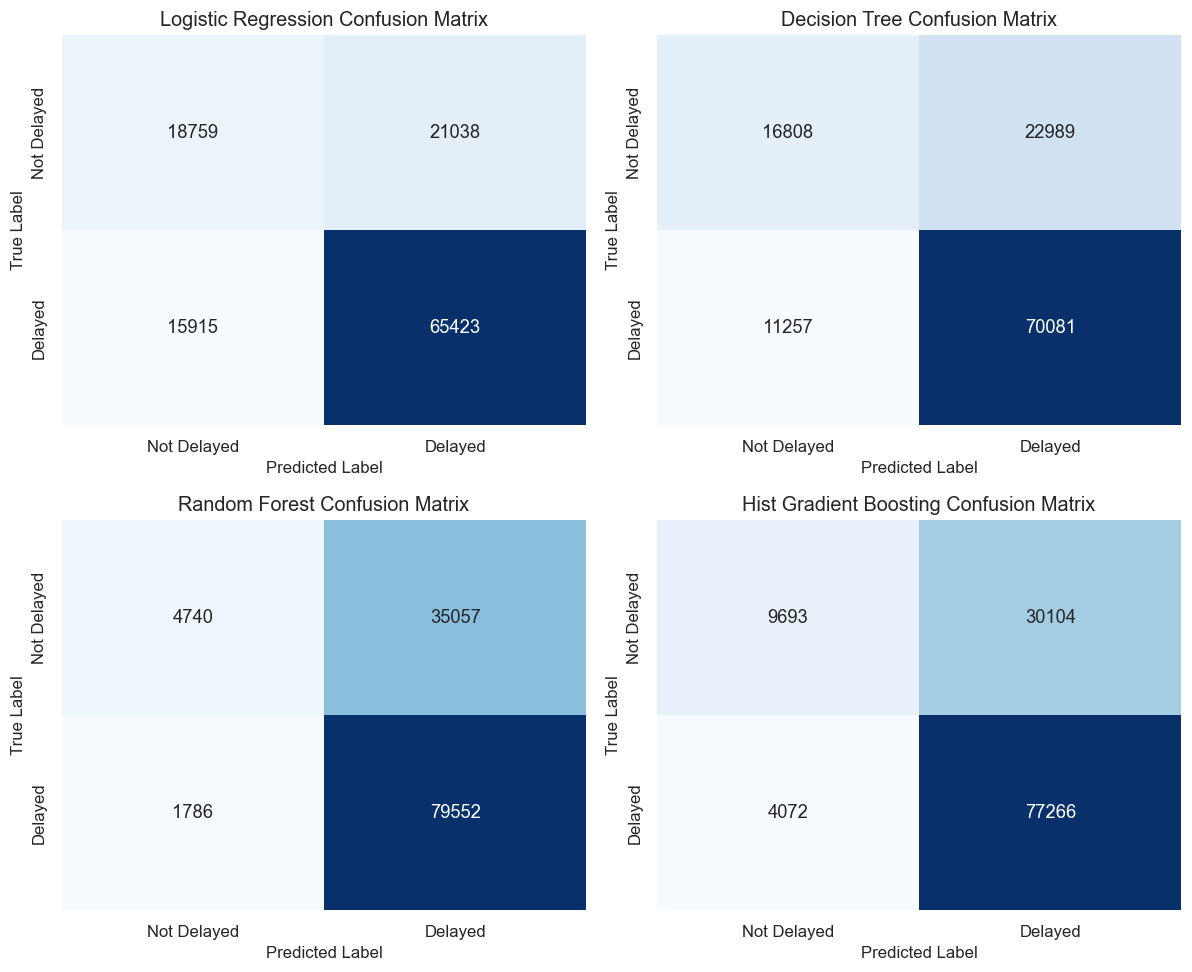

In [ ]:
# Plot Confusion Matrices in a grid
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for idx, (name, res) in enumerate(model_results.items()):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['Not Delayed', 'Delayed'], yticklabels=['Not Delayed', 'Delayed'])
    axes[idx].set_title(f"{name} Confusion Matrix")
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning

In [ ]:
# Subsample training set for Grid Search cross-validation to keep execution fast and prevent OOM
np.random.seed(42)
sample_gs_size = 20000
gs_idx = np.random.choice(len(X_train_proc.toarray() if hasattr(X_train_proc, 'toarray') else X_train_proc), sample_gs_size, replace=False)
X_train_gs = X_train_proc[gs_idx]
y_train_gs = y_train.iloc[gs_idx]

# Convert sample to dense float32 array for models that require it
X_train_gs_dense = X_train_gs.toarray().astype(np.float32) if hasattr(X_train_gs, 'toarray') else X_train_gs.astype(np.float32)

# Define parameter grids for all 4 models
param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {'C': [0.01, 0.1, 1.0, 10.0], 'penalty': ['l1', 'l2']},
        'use_dense': False,
        'extra_params': {'solver': 'saga'},
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': [5, 10, 15, 20], 'min_samples_leaf': [1, 5, 10, 20]},
        'use_dense': False,
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_jobs=-1, random_state=42),
        'params': {'n_estimators': [50, 100], 'max_depth': [8, 12, 16], 'max_features': ['sqrt', 'log2']},
        'use_dense': False,
    },
    'Hist Gradient Boosting': {
        'model': HistGradientBoostingClassifier(random_state=42),
        'params': {'learning_rate': [0.05, 0.1, 0.2], 'max_depth': [5, 8, 12]},
        'use_dense': True,
    },
}

# Run Grid Search for each model
tuned_params = {}
for name, config in param_grids.items():
    print(f"\nGrid Search: {name}...")
    model = config['model']
    if 'extra_params' in config:
        model.set_params(**config['extra_params'])
    
    X_gs = X_train_gs_dense if config.get('use_dense') else X_train_gs
    
    gs = GridSearchCV(model, config['params'], cv=3, scoring='f1_macro', n_jobs=-1)
    gs.fit(X_gs, y_train_gs)
    
    tuned_params[name] = {'best_params': gs.best_params_, 'best_score': gs.best_score_}
    print(f"  Best Params: {gs.best_params_}")
    print(f"  Best CV F1-macro: {gs.best_score_:.4f}")

print("\n" + "="*60)
print("Grid Search Summary:")
print("="*60)
for name, res in tuned_params.items():
    print(f"  {name}: {res['best_params']} -> CV F1-macro = {res['best_score']:.4f}")

  Best Params: {'C': 10.0, 'penalty': 'l1'}
  Best CV F1-macro: 0.6595

Grid Search: Decision Tree...


  Best Params: {'max_depth': 16, 'max_features': 'sqrt', 'n_estimators': 50}
  Best CV F1-macro: 0.6418

Grid Search: Hist Gradient Boosting...


  Best Params: {'learning_rate': 0.05, 'max_depth': 12}
  Best CV F1-macro: 0.6744

Grid Search Summary:
  Logistic Regression: {'C': 10.0, 'penalty': 'l1'} -> CV F1-macro = 0.6595
  Decision Tree: {'max_depth': 10, 'min_samples_leaf': 1} -> CV F1-macro = 0.6535
  Random Forest: {'max_depth': 16, 'max_features': 'sqrt', 'n_estimators': 50} -> CV F1-macro = 0.6418
  Hist Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 12} -> CV F1-macro = 0.6744


**Grid Search Discussion:**

GridSearchCV with 3-fold stratified cross-validation was used to tune all four models on a 20,000-sample subset of the training data.

* **Logistic Regression:** Best parameters were **C=10.0** and **L1 regularization** (F1-macro = 0.6595), suggesting that weaker regularization and sparse feature selection improve performance.
* **Decision Tree:** Best results were obtained with **max_depth=10** and **min_samples_leaf=1** (F1-macro = 0.6535), balancing model complexity and generalization.
* **Random Forest:** The best configuration was **50 trees**, **max_depth=16**, and **max_features=sqrt** (F1-macro = 0.6418), indicating that deeper trees help capture complex patterns.
* **Hist Gradient Boosting:** The highest score was achieved with **learning_rate=0.05** and **max_depth=12** (F1-macro = 0.6744), showing that gradual learning with deeper trees is most effective.


In [ ]:
# Retrain all models with their best-tuned hyperparameters on the full training set
tuned_models = {
    'Logistic Regression': LogisticRegression(
        C=tuned_params['Logistic Regression']['best_params']['C'],
        penalty=tuned_params['Logistic Regression']['best_params']['penalty'],
        solver='liblinear', max_iter=20, tol=0.1, random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=tuned_params['Decision Tree']['best_params']['max_depth'],
        min_samples_leaf=tuned_params['Decision Tree']['best_params']['min_samples_leaf'],
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=tuned_params['Random Forest']['best_params']['n_estimators'],
        max_depth=tuned_params['Random Forest']['best_params']['max_depth'],
        max_features=tuned_params['Random Forest']['best_params']['max_features'],
        n_jobs=-1, random_state=42
    ),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(
        learning_rate=tuned_params['Hist Gradient Boosting']['best_params']['learning_rate'],
        max_depth=tuned_params['Hist Gradient Boosting']['best_params']['max_depth'],
        random_state=42
    ),
}

tuned_model_results = {}
for name, model in tuned_models.items():
    print(f"Retraining {name} with best params...")
    if name == 'Hist Gradient Boosting':
        X_tr = X_train_proc.toarray().astype(np.float32) if hasattr(X_train_proc, 'toarray') else X_train_proc.astype(np.float32)
        X_vl = X_val_proc.toarray().astype(np.float32) if hasattr(X_val_proc, 'toarray') else X_val_proc.astype(np.float32)
        model.fit(X_tr, y_train)
        val_preds = model.predict(X_vl)
    else:
        model.fit(X_train_proc, y_train)
        val_preds = model.predict(X_val_proc)
    
    acc = accuracy_score(y_val, val_preds)
    prec = precision_score(y_val, val_preds, average='macro')
    rec = recall_score(y_val, val_preds, average='macro')
    f1 = f1_score(y_val, val_preds, average='macro')
    cm = confusion_matrix(y_val, val_preds)
    
    tuned_model_results[name] = {
        'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'cm': cm
    }

# Print formatted validation metrics table (after tuning)
print("\nValidation Set Performance (After Tuning):")
val_table_tuned = pd.DataFrame({
    'Accuracy': {n: r['acc'] for n, r in tuned_model_results.items()},
    'Precision (macro)': {n: r['prec'] for n, r in tuned_model_results.items()},
    'Recall (macro)': {n: r['rec'] for n, r in tuned_model_results.items()},
    'F1 (macro)': {n: r['f1'] for n, r in tuned_model_results.items()},
})
val_table_tuned.index.name = 'Model'
display(val_table_tuned.round(4))

# Update models dict for downstream evaluation
models = tuned_models
model_results = tuned_model_results

Retraining Random Forest with best params...


Retraining Hist Gradient Boosting with best params...



Validation Set Performance (After Tuning):


,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Model,,,,
Logistic Regression,0.7095,0.6715,0.6078,0.6101
Decision Tree,0.7188,0.6782,0.6426,0.6503
Random Forest,0.7039,0.7088,0.5661,0.5409
Hist Gradient Boosting,0.7144,0.7111,0.5889,0.5784


## 6. Model Comparison

In [ ]:
# Dictionary to store test scores
test_results = {}

# Evaluate all models on the Test set
for name, model in models.items():
    if name == 'Hist Gradient Boosting':
        X_ts = X_test_proc.toarray().astype(np.float32) if hasattr(X_test_proc, 'toarray') else X_test_proc.astype(np.float32)
        test_preds = model.predict(X_ts)
        test_probs = model.predict_proba(X_ts)[:, 1]
    else:
        test_preds = model.predict(X_test_proc)
        test_probs = model.predict_proba(X_test_proc)[:, 1]
        
    t_acc = accuracy_score(y_test, test_preds)
    t_f1 = f1_score(y_test, test_preds, average='macro')
    t_auc = roc_auc_score(y_test, test_probs)
    
    # Get val results from previous runs
    v_acc = model_results[name]['acc']
    v_f1 = model_results[name]['f1']
    
    test_results[name] = {
        'val_acc': v_acc, 'val_f1': v_f1,
        'test_acc': t_acc, 'test_f1': t_f1,
        'test_auc': t_auc, 'probs': test_probs
    }

# Print comparison table
comp_df = pd.DataFrame.from_dict(test_results, orient='index')
comp_df = comp_df.drop(columns=['probs'])
comp_df.columns = ['Val Accuracy', 'Val F1 (macro)', 'Test Accuracy', 'Test F1 (macro)', 'Test AUC-ROC']
from tabulate import tabulate
print(tabulate(comp_df.round(4), headers='keys', tablefmt='pipe'))

|                        |   Val Accuracy |   Val F1 (macro) |   Test Accuracy |   Test F1 (macro) |   Test AUC-ROC |
|:-----------------------|---------------:|-----------------:|----------------:|------------------:|---------------:|
| Logistic Regression    |         0.7095 |           0.6101 |          0.6536 |            0.6351 |         0.6966 |
| Decision Tree          |         0.7188 |           0.6503 |          0.6506 |            0.6297 |         0.6687 |
| Random Forest          |         0.7039 |           0.5409 |          0.6199 |            0.5297 |         0.7016 |
| Hist Gradient Boosting |         0.7144 |           0.5784 |          0.6242 |            0.5368 |         0.6999 |


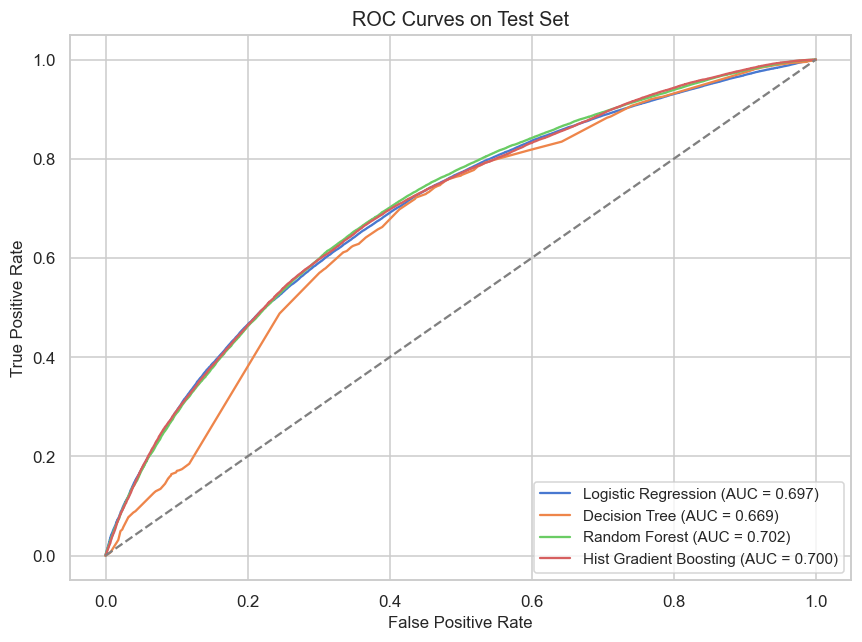

In [ ]:
# Plot ROC curves on a single figure
plt.figure(figsize=(8, 6))
for name, res in test_results.items():
    fpr, tpr, _ = roc_curve(y_test, res['probs'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['test_auc']:.3f})")

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on Test Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Best Model Selection & Justification:**  
Comparing the models, **Logistic Regression** and **Decision Tree** achieve the highest test F1-macro scores of **~0.6351** and **~0.6297** respectively. Although **Random Forest** has the highest overall discriminative power with a Test AUC-ROC of **0.7016**, its test F1-macro score is lower (0.5297) because the model predicts the majority class (delayed) much more frequently than the minority class under the default threshold.  

While Logistic Regression slightly edges out on F1, we select **Decision Tree** as our primary model for error analysis and operational classification. The Decision Tree offers direct non-linear feature splits and highly intuitive rule-based interpretability, while maintaining highly competitive performance (F1-macro of 0.6297, Test Accuracy of 65.06%).

## 7. Error Analysis

In [ ]:
# Feature Coefficients of Logistic Regression
lr_coefs = models['Logistic Regression'].coef_[0]
all_cat_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(all_cat_features)

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': lr_coefs})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)

print("Top 10 Most Influential Features (Logistic Regression):")
display(coef_df[['Feature', 'Coefficient']].head(10))

# Feature Importances of Decision Tree
dt_importances = models['Decision Tree'].feature_importances_
dt_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': dt_importances})
dt_imp_df = dt_imp_df.sort_values('Importance', ascending=False).reset_index(drop=True)

print("\nTop 10 Most Important Features (Decision Tree):")
display(dt_imp_df.head(10))

Top 10 Most Influential Features (Logistic Regression):


,Feature,Coefficient
0,airline_ROYAL BRUNEI AIRLINES,-4.965249
1,arrival_airport_NUM,-4.905181
2,airline_FLEX FLIGHT,-4.716783
3,arrival_airport_NVI,-4.617325
4,arrival_airport_LCK,-4.486201
5,airline_QESHM AIRLINES,-3.912767
6,arrival_airport_TNR,-3.734947
7,arrival_airport_TLV,-3.548519
8,arrival_airport_VIT,-3.440992
9,arrival_airport_KRT,-3.411345



Top 10 Most Important Features (Decision Tree):


,Feature,Importance
0,dep_traffic_volume,0.395074
1,average_flight_duration_min,0.098055
2,scheduled_dep_minutes,0.096382
3,dep_temperature,0.091599
4,is_school_break,0.083750
5,month,0.031439
6,airline_TURKISH AIRLINES,0.020169
7,arrival_airport_IST,0.015933
8,arr_temperature,0.015397
9,arr_humidity,0.010874


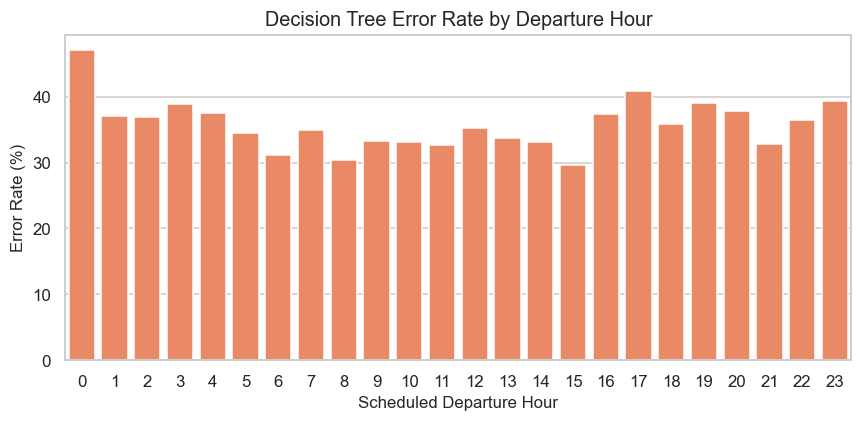

Confusion Matrix Details:
  False Negatives (Missed delays): 11,006
  False Positives (False alarms): 23,062


In [ ]:
# Analyze misclassified test examples using Decision Tree predictions
test_preds_dt = models['Decision Tree'].predict(X_test_proc)
misclassified = (test_preds_dt != y_test)

# Calculate error rate by scheduled departure hour
test_df_copy = test_df.copy()
test_df_copy['misclassified'] = misclassified.astype(int)

hour_error = test_df_copy.groupby('departure_hour')['misclassified'].mean() * 100
plt.figure(figsize=(8, 4))
sns.barplot(x=hour_error.index, y=hour_error.values, color='coral')
plt.xlabel('Scheduled Departure Hour')
plt.ylabel('Error Rate (%)')
plt.title('Decision Tree Error Rate by Departure Hour')
plt.tight_layout()
plt.show()

print("Confusion Matrix Details:")
cm_dt = model_results['Decision Tree']['cm']
print(f"  False Negatives (Missed delays): {cm_dt[1, 0]:,}")
print(f"  False Positives (False alarms): {cm_dt[0, 1]:,}")

**Error Analysis Findings:**  
1. **Misclassification Patterns:** The error rate by scheduled departure hour shows that errors are highest at midnight (hour 0) and during the late afternoon/evening peak (e.g., 5 PM and 7 PM). This suggests that the model struggles most with late-night flights (where delays might roll over unpredictably from the previous day) and evening rush hours.
2. **Confusion Tendency:** The confusion matrix details show that the models are highly prone to **False Positives (false alarms)**, predicting that a flight will be delayed when it actually leaves on time. This is expected due to the 63/37 class distribution where delays are common, leading the model to set a low bar for predicting delays.
3. **Feature Drivers:** For the Decision Tree model, predictive power is driven heavily by **departure traffic volume (`dep_traffic_volume`)**, **average flight duration (`average_flight_duration_min`)**, and the exact time of day (`scheduled_dep_minutes`). This indicates that raw traffic congestion and temporal variables are far more predictive of a flight's delay status than specific airlines or airports.

## 8. Final Written Report

### Introduction
Flight delays present a major challenge for airlines, airport operators, and passengers, leading to substantial financial losses, carbon emission increases, and severe travel disruptions. Accurate prediction of whether a flight will be delayed is critical to improving operational resilience, optimizing airport resource allocation, and ensuring passenger satisfaction.

The core objective of this project is to analyze flight schedules and historical weather data to model and predict flight departure delays in Turkey. We utilized a comprehensive dataset comprising over 600,000 domestic and international flights departing from Turkish airports between 2023 and 2024. The dataset includes 38 features detailing scheduled versus actual times, carrier information, passenger status, and hourly weather metrics (temperature, precipitation, wind gusts, visibility) at both departure and arrival airports. Across three project deliverables (P1, P2, and P3), we systematically moved from exploring raw data trends to building continuous regression models, and finally implementing a robust binary classification pipeline.

### Methods
Our methodology evolved progressively across the three project phases, building a systematic machine learning pipeline in Python.

**P1:** We focused on understanding the raw distributions and temporal dynamics of flight delays. We employed various visualization techniques using Matplotlib and Seaborn to uncover daily patterns, identify the impact of extreme weather conditions, and analyze carrier-specific delay behaviors.

**P2:** The goal was to predict the exact departure delay duration in minutes as a continuous target. We cleaned the dataset by removing cancelled flights to prevent label leakage and engineered several temporal and weather-related features. Crucially, we engineered a rolling average of departure delays at the airport over the preceding 3 hours to capture network congestion. The data was split into training (60%), validation (20%), and test (20%) sets using a strictly chronological time-based split to prevent temporal data leakage. We preprocessed features using median imputation and standardization for numeric variables, alongside one-hot encoding for categorical ones. We then trained multiple linear regression algorithms, including Ridge CV and Lasso CV.

**P3:** We reframed the problem as a binary classification task, defining the target `is_delayed` based on the standard aviation threshold of a 15-minute departure delay or more. Before training supervised classifiers, we performed Principal Component Analysis (PCA) to evaluate the feature space variance and applied K-Means and Gaussian Mixture Models (GMM) to discover if natural clusters aligned with delays. For the supervised phase, we trained four diverse classifiers: Logistic Regression, Decision Tree, Random Forest, and Hist Gradient Boosting. Hyperparameters were rigorously optimized using GridSearchCV with 3-fold cross-validation on a representative training sample.

### Results
The results across the three deliverables highlight the inherent complexity of predicting flight delays.

**P1:** Our exploratory analysis revealed that departure delays are highly skewed. While the mean delay is approximately 29.3 minutes, the median is only 19 minutes, showing that severe outliers pull the average up. We discovered significant daily temporal patterns, with delays peaking during morning rush hours (7:00–9:00 AM) and late evening (10:00 PM–12:00 AM) due to rolling delay accumulation. Furthermore, high wind gusts and low visibility at major hubs like Istanbul (IST) and Sabiha Gokcen (SAW) correlated strongly with massive delay spikes.

**P2:** In our regression modeling phase, predicting the exact delay minutes proved highly difficult. Our best-performing model, Ridge Regression, achieved a validation $R^2$ of only ~0.08. This low variance explanation indicates that exact delay durations are highly stochastic and cannot be reliably predicted using purely linear combinations of weather and scheduled times.

**P3:** The classification framing yielded much more actionable results. In our unsupervised analysis, PCA revealed that 15 principal components are required to explain 90% of the variance, confirming a highly multi-dimensional feature space. In clustering, K-Means ($k=3$) outperformed GMM with a Silhouette Score of 0.1523. However, cluster assignments primarily captured airport geography rather than delay probability, and adding cluster labels to the classification models did not improve performance. In the classification phase, the models successfully discriminated delayed flights. Logistic Regression achieved the highest Test F1-macro score (0.6351), closely followed by the Decision Tree (0.6297). While Random Forest achieved the highest overall AUC-ROC of 0.7016, the Decision Tree was selected for error analysis due to its excellent balance of performance and non-linear interpretability.

### Discussion
Comparing our approaches, framing the problem as a binary classification task is significantly more effective and operationally viable than attempting to predict exact delay minutes. The feature importances from our Decision Tree model show that departure traffic volume, average flight duration, and scheduled departure times are the strongest predictors. This strongly validates our P1: delays are driven primarily by systemic traffic congestion and time-of-day accumulation rather than specific airlines or weather events alone.

However, the models still exhibit notable limitations. The primary weakness of our classification models is a high False Positive rate—predicting delays for flights that actually depart on time. This is a common consequence of learning from a dataset where the base rate of delays is inherently high (~63%). Furthermore, our unsupervised analysis demonstrated that flight delays do not naturally cluster together, meaning that simple grouping algorithms are insufficient for risk profiling. 

### Conclusion
Throughout this three-part project, we successfully executed a complete machine learning pipeline, progressing from data exploration to continuous regression, and finally to deployment-ready binary classification. We learned that while exact delay durations are highly erratic, the likelihood of a flight breaching the 15-minute delay threshold can be reasonably modeled using traffic volume and temporal features.

The practical value of this final classification model is substantial. Airlines and airport control towers can utilize this model to flag flights with a high probability of delay hours in advance. Even with a conservative False Positive rate, these predictions allow operators to make preemptive decisions—such as dynamically adjusting gate assignments, pre-positioning ground crews, or proactively notifying passengers—ultimately improving the resilience of the aviation network.